## Levantar el csv

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

random_state = 42
np.random.seed(random_state)

In [2]:
df = pd.read_csv('train.csv')


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   popularity        4200 non-null   int64  
 1   duration_ms       4200 non-null   int64  
 2   explicit          4200 non-null   bool   
 3   danceability      4200 non-null   float64
 4   energy            4200 non-null   float64
 5   key               4200 non-null   int64  
 6   loudness          4200 non-null   float64
 7   mode              4200 non-null   int64  
 8   speechiness       4200 non-null   float64
 9   acousticness      4200 non-null   float64
 10  instrumentalness  4200 non-null   float64
 11  liveness          4200 non-null   float64
 12  valence           4200 non-null   float64
 13  tempo             4200 non-null   float64
 14  time_signature    4200 non-null   int64  
 15  Expected          4200 non-null   str    
 16  Id                4200 non-null   int64  
dtypes: boo

In [4]:
y = df['Expected']

X = df.drop('Expected', axis=1)

In [5]:
y.unique()

<StringArray>
['jazz', 'electronic', 'hip-hop', 'acoustic', 'rock', 'classical']
Length: 6, dtype: str

## Analisis Exploratorio

### Balanceo de Clases

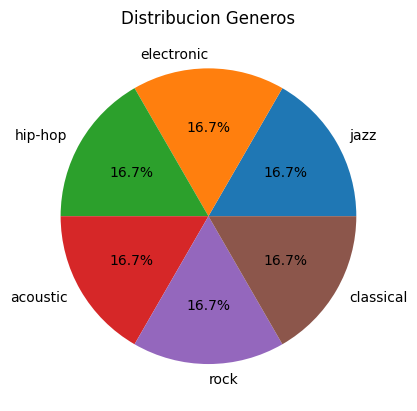

In [6]:
from matplotlib import pyplot as plt

plt.pie(df['Expected'].value_counts(), labels = y.unique(), autopct= '%1.1f%%')
plt.title("Distribucion Generos")
plt.show()

En este grafico de torta podemos ver la distribucion de las seis clases.

Como se ve en el grafico, las clases estan perfectamente distribuidas, por lo que, tenemos un dataset perfectamente balanceado.

### Visualizacion de Features

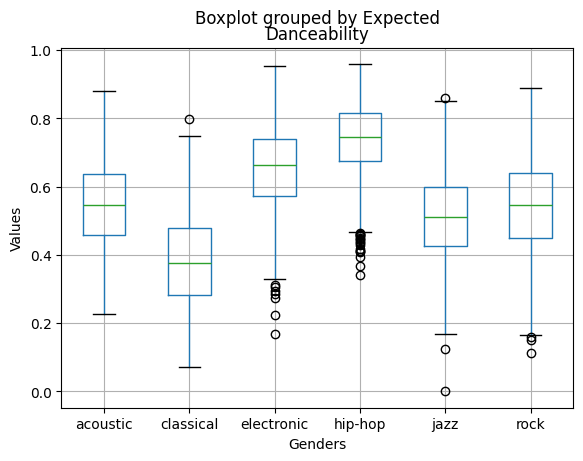

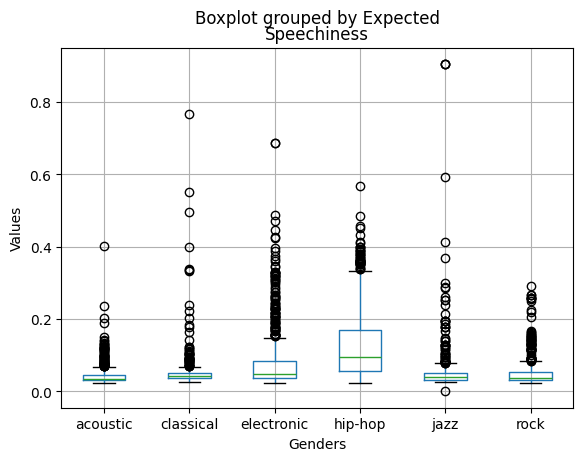

In [7]:
df.boxplot(column="danceability", by='Expected')
plt.xlabel("Genders")
plt.ylabel("Values")
plt.title("Danceability")
plt.show()

df.boxplot(column="speechiness", by='Expected')
plt.xlabel("Genders")
plt.ylabel("Values")
plt.title("Speechiness")
plt.show()

En estos boxplots, podemos ver el nivel de los features en los distintos generos.

Vemos, por ejemplo, que danceability y speechiness son buenos predictores para el genero "hip-hop"

### Separamos en Train y Test

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                  train_size = 0.8,
                                                  random_state = random_state,
                                                  stratify = y)

### Definimos Map@3

In [9]:
def mapk(y_true, y_pred_proba, k=3):
    """
    y_true: array (n_samples)
    y_pred_proba: array (n_samples, n_classes)
    """

    # Obtener top-k indices
    top_k = np.argsort(y_pred_proba, axis=1)[:, -k:][:, ::-1]

    score = 0.0

    for i in range(len(y_true)):
        true_label = y_true[i]
        preds = top_k[i]

        if true_label in preds:
            rank = np.where(preds == true_label)[0][0] + 1
            score += 1.0 / rank

    return score / len(y_true)

In [10]:
from sklearn.metrics import make_scorer

def map3_scorer(estimator, X, y):
    proba = estimator.predict_proba(X)
    return mapk(y, proba, k=3)

## Modelo Random Forest

In [11]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(max_depth=20, random_state=512)

### Hacemos Randomized search para optimizar hiperparametros
Optimizamos la métrica del tp, f1-macro.

In [12]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from scipy.stats import uniform

parameters = {'n_estimators': list(range(50, 500)),
              'criterion':('gini', 'entropy', 'log_loss'),
              'max_depth': list(range(5, 41)),
              'min_samples_split': list(range(2, 21)),
              'min_samples_leaf': list(range(1, 16)),
              'min_impurity_decrease': uniform(loc = 0, scale = 0.1)
             }

# RandomizedSearchCV recibe un estimador que debe tener implementado el método score().
# param_distributions es un diccionario que puede combinar conjuntos de valores y distribuciones continuas o discretas.
# Se pueden definir los k-folds para cross-validation. Por defecto, cv = 5.
rs = RandomizedSearchCV(estimator = RandomForestClassifier(n_jobs=-1, random_state = 512),
                        param_distributions = parameters,
                        n_iter = 100,
                        scoring = 'f1_macro',
                        cv = KFold(4),
                        random_state = 22,
                        n_jobs = -1)

In [13]:
rs.fit(X_train, y_train)
# Fiteamos la busqueda de 100 iteraciones y escribimos
# los parametros a mano del modelo optimizado

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...dom_state=512)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ('gini', ...), 'max_depth': [5, 6, ...], 'min_impurity_decrease': <scipy.stats....0028EA0B8AA50>, 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies th

In [23]:
# Traemos los valores a mano luego de correr 10min
RF_opt = RandomForestClassifier(criterion='log_loss', max_depth=32,
                       min_impurity_decrease=np.float64(0.0005999501419766796),
                       min_samples_leaf=13, min_samples_split=7,
                       n_estimators=210, n_jobs=-1, random_state=512)

RF_opt.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",210
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'log_loss'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",32
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",7
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",13
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",np.float64(0....9501419766796)
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a c

## Feature Importance
Vemos la importancia de las features en la evaluacion final

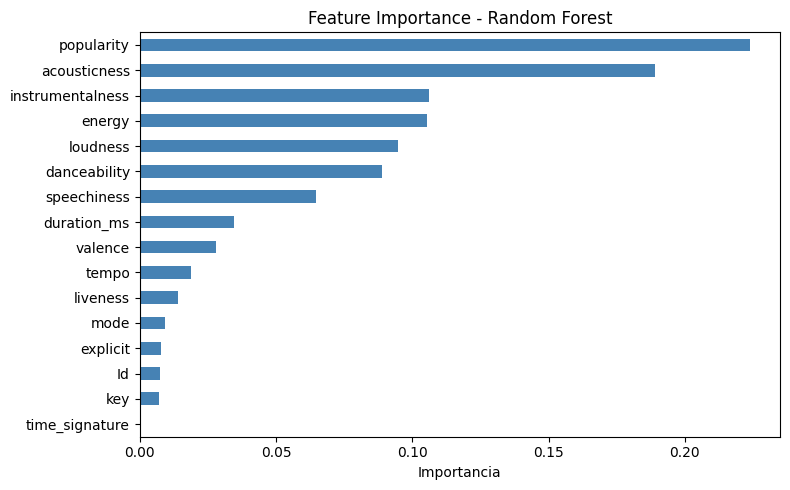

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(RF_opt.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)

importances.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

## Modelo XGBoost

In [25]:
import xgboost as xgb

clf2 = xgb.XGBClassifier(
    num_class=6,   # Número de géneros
    random_state=42,
)

In [26]:
#Usamos xgboost entonces
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)
y_test = le.fit_transform(y_test)
y_train = le.fit_transform(y_train)

### Hacemos Random Search para optimizar hiperparametros
Optimizamos MAP@3

In [88]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import uniform, randint

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

# Espacio de búsqueda
parameters = {
    "n_estimators": randint(300, 900),
    "learning_rate": uniform(0.03, 0.2),
    "max_depth": randint(4, 10),
    "min_child_weight": randint(1, 6),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
    "gamma": uniform(0, 3)
}

rs_boost = RandomizedSearchCV(
    xgb.XGBClassifier(num_class=6, random_state=512),
    param_distributions=parameters,
    n_iter=120,
    scoring=map3_scorer,   #Optimizar map@3
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    error_score='raise'
)

# rs_boost.fit(X_train, y_train)
# Corrimos la busqueda y escribimos a mano los mejores parametros



In [89]:
#Traemos los parámetros a mano luego de correr 120 iteraciones
# de random search en  15min
XGB_opt = xgb.XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.881928717897877), device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=np.float64(0.027591154849888944), grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.05029430857320642), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=1, monotone_constraints=None,
              subsample=np.float64(0.845684126075868),
              n_estimators=637, n_jobs=None, num_class=6)


In [90]:
df2 = pd.read_csv('test.csv')
XGB_opt.fit(X, y)

Y_pred = XGB_opt.predict(df2) #Las predicciones estan encodeadas

In [91]:
submission = pd.DataFrame({
    "Id": df2["Id"],
    "Expected": le.inverse_transform(Y_pred) #Revierto los cambios del encodeo
})

# Guardar CSV
submission.to_csv("submission.csv", index=False)

## Comparacion entre modelos

### Resultados RandomForest

Score en test: 0.7959662455422823


Score en cv: 0.7814   SD: 0.0114


MAP@3 Score: 0.8722222222222223


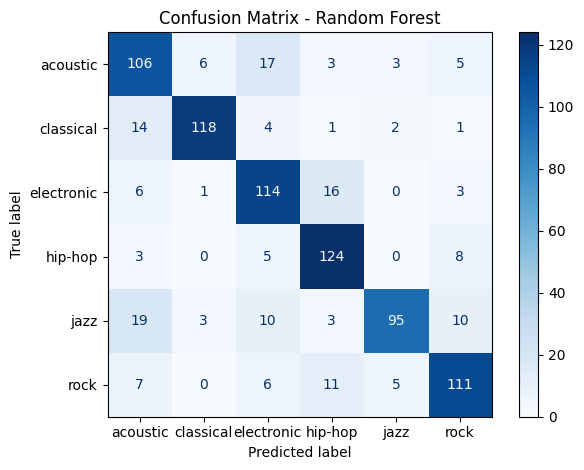

In [100]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

RF_opt.fit(X_train, y_train)
y_pred = RF_opt.predict(X_test)
print("Score en test:", f1_score(y_test, y_pred, average="macro"))
print("\n")

scores_rf = cross_val_score(RF_opt, X, y, scoring="f1_macro", cv = KFold(4))
print(f'Score en cv: {scores_rf.mean():.4f}' + f'   SD: {scores_rf.std():.4f}') #f1 score optimizado
print("\n")

proba_rf = RF_opt.predict_proba(X_test)
map3_rf = mapk(y_test, proba_rf, k=3)
print("MAP@3 Score:", map3_rf)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()



### Resultados XGBoost

Score en test: 0.8582802038756038


Score en cv: 0.8358  SD: 0.0132


MAP@3 Score:  0.9097222222222225


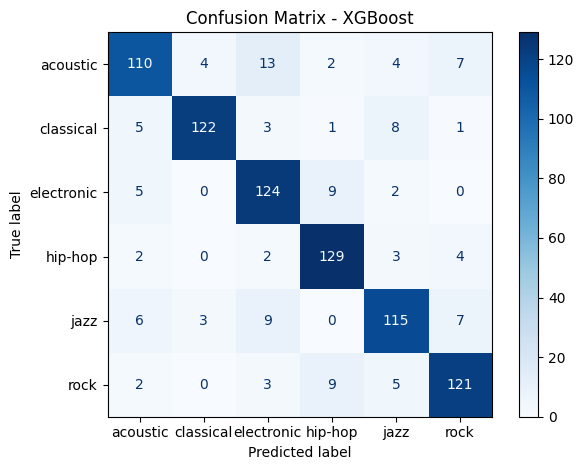

In [ ]:
XGB_opt.fit(X_train, y_train)
y_pred = XGB_opt.predict(X_test)
print("Score en test:", f1_score(y_test, y_pred, average="macro"))
print("\n")

scores_xgb = cross_val_score(XGB_opt, X, y, scoring="f1_macro", cv = KFold(4))
print(f'Score en cv: {scores_xgb.mean():.4f}' + f'  SD: {scores_xgb.std():.4f}') #f1 score optimizado
print("\n")

proba_xgb = XGB_opt.predict_proba(X_test)
map3_xgb = mapk(y_test, proba_xgb, k=3)
print("MAP@3 Score: ", map3_xgb)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.tight_layout()
plt.show()